In [1]:
import torch
import torchvision
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset, random_split
from torch import nn, optim

from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import kagglehub
from tqdm import tqdm

c:\Users\Evgeny\Programming\cv-classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# CV. Проведение исследований с моделями классификации

## Выбор начальных условий

### Выбор набора данных и обоснование

В рамках данной работы был выбран датасет ["Drone vs Bird"](https://www.kaggle.com/datasets/muhammadsaoodsarwar/drone-vs-bird) с платформы Kaggle.

Задача различения птиц и беспилотных летательных аппаратов широко встречается в реальных системах:
- Системы видеонаблюдения и безопасности
- Аэропорты и авиационная безопасность
- Военные и охранные системы
- Системы мониторинга природы

Необходимо отличать дрон, который может являться потенциальной угрозой, от естественных объектов, таких как птицы. И наоборот, при наблюдении за птицами необходимо исключать ложные срабатывания системы.

Таким образом, датасет хорошо подходит для исследования методов компьютерного зрения и оценки качества моделей классификации.


In [3]:
path = kagglehub.dataset_download("muhammadsaoodsarwar/drone-vs-bird", output_dir="./data")
print("Path to dataset files:", path)

Path to dataset files: ./data


In [4]:
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

path += "/dataset"
dataset = ImageFolder(path, transform=base_transform)
dataset.classes

['bird', 'drone']

Разбиение датасета на `train` и `test`

In [5]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

train_subset, test_subset = random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_indices = train_subset.indices
test_indices = test_subset.indices

train_data = Subset(dataset, train_indices)
test_data  = Subset(dataset, test_indices)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

Text(0.5, 1.0, 'Распределение классов')

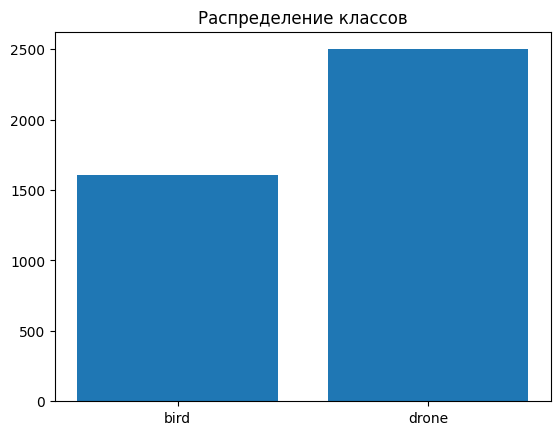

In [6]:
values = np.bincount(dataset.targets)
names = dataset.classes

plt.bar(names, values)
plt.title("Распределение классов")

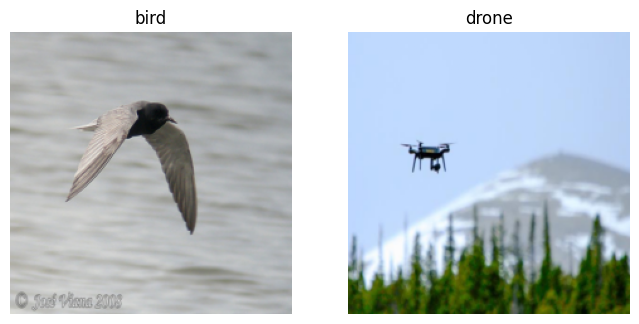

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

shown = [False] * len(dataset.classes)

for img, label in dataset:
    if not shown[label]:
        axes[label].imshow(img.permute(1, 2, 0))
        axes[label].set_title(dataset.classes[label])
        axes[label].axis('off')
        shown[label] = True
    if all(shown):
        break

### Выбор метрик

Для оценки качества моделей в задаче бинарной классификации можно использовать метрики *Precision* и *Recall*.
Для снижения количества ложных тревог в системах безопасности и повышения точности предсказаний используют *Precision*:
$$ Precision = \frac{TP}{TP + FP} $$
Для обнаружения всех дронов и минимизации пропусков используют *Recall* (полноту):
$$ Recall = \frac{TP}{TP + FN} $$

В качестве **основной метрики** выбрана *F1-score*:
$$ F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall} $$
Она обеспечивает баланс между  *Precision* и *Recall*.

В качестве вспомогательной метрики также будет использоваться *Accuracy*, так как она даёт общее представление о качестве модели.


## Создание бейзлайна и оценка качества

### Обучение моделей


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [8]:
def print_metrics(model, loader):
    targets, preds = evaluate(model, loader)
    print(f"Accuracy: {accuracy_score(targets, preds)}\n"
          f"F1-Score: {f1_score(targets, preds)}\n")

def evaluate(model, loader):
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            pred = out.argmax(dim=1)

            preds.extend(pred.cpu().numpy())
            targets.extend(y.cpu().numpy())

    return targets, preds

In [9]:
def train_model(model, epochs=3):
    model=model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x, y in tqdm(train_loader):
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print_metrics(model, test_loader)
    return model

CNN baseline:

In [10]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.fc = nn.Linear(resnet.fc.in_features, 2)

resnet = train_model(resnet)

100%|██████████| 103/103 [00:35<00:00,  2.89it/s]


Accuracy: 0.98661800486618
F1-Score: 0.9891196834817013



100%|██████████| 103/103 [00:35<00:00,  2.88it/s]


Accuracy: 0.9951338199513382
F1-Score: 0.9960707269155207



100%|██████████| 103/103 [00:32<00:00,  3.17it/s]


Accuracy: 0.9963503649635036
F1-Score: 0.9970559371933267



Transformer baseline:

In [20]:
vit = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
vit.heads.head = nn.Linear(vit.heads.head.in_features, 2)

In [21]:
vit = train_model(vit)

100%|██████████| 103/103 [02:39<00:00,  1.55s/it]


Accuracy: 0.9829683698296837
F1-Score: 0.98635477582846



100%|██████████| 103/103 [02:47<00:00,  1.62s/it]


Accuracy: 0.9525547445255474
F1-Score: 0.9607250755287009



100%|██████████| 103/103 [03:05<00:00,  1.80s/it]


Accuracy: 0.9927007299270073
F1-Score: 0.9940944881889764



### Оценка качества моделей

В ходе экспериментов модель `ResNet18` показала высокое и стабильное качество на тестовой выборке.

Результаты:
- *Accuracy*: 0.987-0.996
- *F1-Score*: 0.989-0.997

Модель демонстрирует очень высокую точность классификации. *F1-Score* стабильно выше 0.99, что говорит о низком количестве ложных срабатываний и хорошем балансе между *Precision* и *Recall*.

Разброс значений между эпохами небольшой - обучение устойчивое.

Построим *Confusion Matrix* для этой модели.

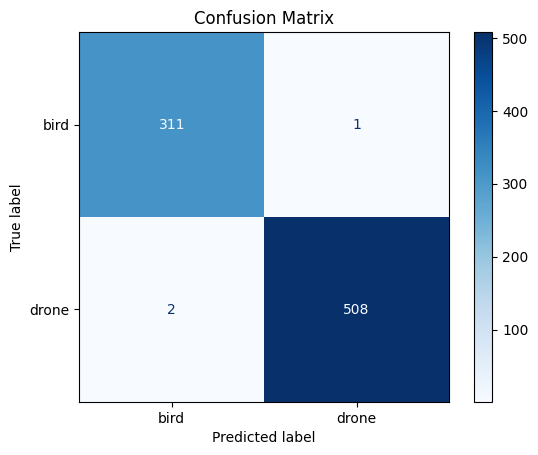

In [11]:
def plot_confusion_matrix(model, loader, class_names):
    targets, preds = evaluate(model, loader)

    cm = confusion_matrix(targets, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=class_names)
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()

plot_confusion_matrix(resnet, test_loader, class_names=dataset.classes)

Модель показывает очень хорошее качество, всего 3 изображния из тестовой выборки были определены неверно. Посмотрим на них.

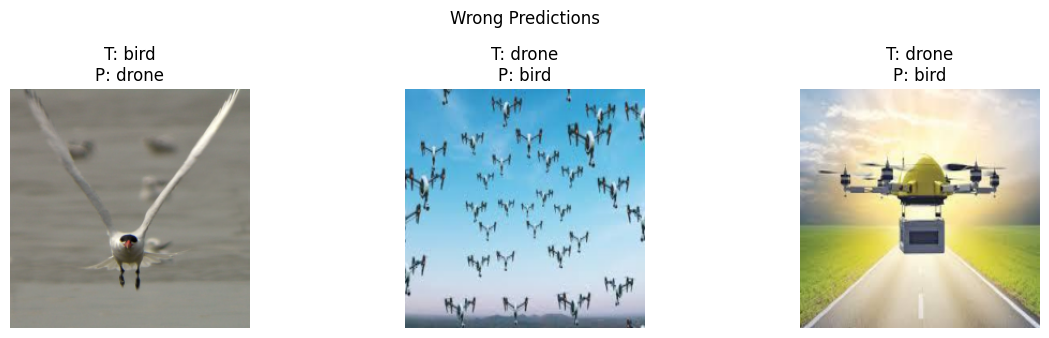

In [12]:
def show_wrong_predictions(model, loader, class_names, max_images=6):
    model.eval()
    wrong_images = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)
            preds = torch.argmax(out, dim=1).cpu()

            for img, true, pred in zip(x.cpu(), y, preds):
                if true != pred:
                    wrong_images.append((img, true.item(), pred.item()))
                if len(wrong_images) >= max_images:
                    break
            if len(wrong_images) >= max_images:
                break

    plt.figure(figsize=(12, 6))

    for i, (img, true, pred) in enumerate(wrong_images):
        plt.subplot(2, 3, i+1)

        img = img.permute(1, 2, 0).numpy()

        img = np.clip(img, 0, 1)

        plt.imshow(img)
        plt.title(f"T: {class_names[true]}\nP: {class_names[pred]}")
        plt.axis("off")

    plt.suptitle("Wrong Predictions")
    plt.tight_layout()
    plt.show()

show_wrong_predictions(resnet, test_loader, dataset.classes)

Модель `ViT` также показала высокие результаты, однако с большей нестабильностью по сравнению с CNN.

Результаты:
- *Accuracy*: 0.983-0.993
- *F1-Score*: 0.961-0.994

Средний уровень качества этой модели немного ниже, чем у `ResNet18`, также присутствует заметная вариативность между эпохами. Лучшие значения приближаются к CNN, но не превосходят его.

Несмотря на то, что `ViT` является более современной архитектурой, в данном эксперименте свёрточная сеть `ResNet18` показала более высокое и стабильное качество.
Причиной может являться недостаточный размер датасета для модели `ViT`. Также дело может быть в самих изображениях: объекты могут занимать разную часть изображения, иметь разный масштаб, а на некторых изображениях присутствует сильный фон. В таких условиях свёрточные сети работают лучше, чем трансформерные.

Построим *Confusion Matrix* и определим неверно предсказанные изображения для этой модели.

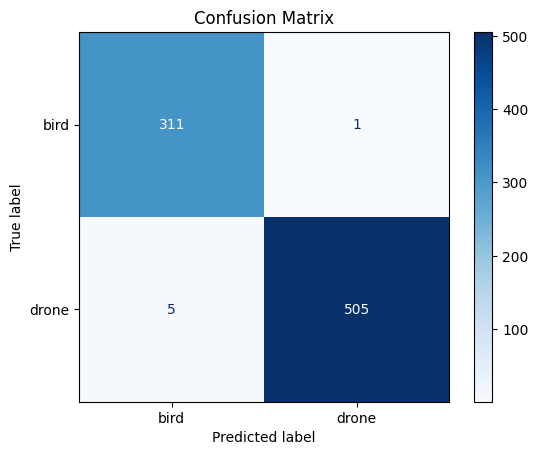

In [22]:
plot_confusion_matrix(vit, test_loader, class_names=dataset.classes)

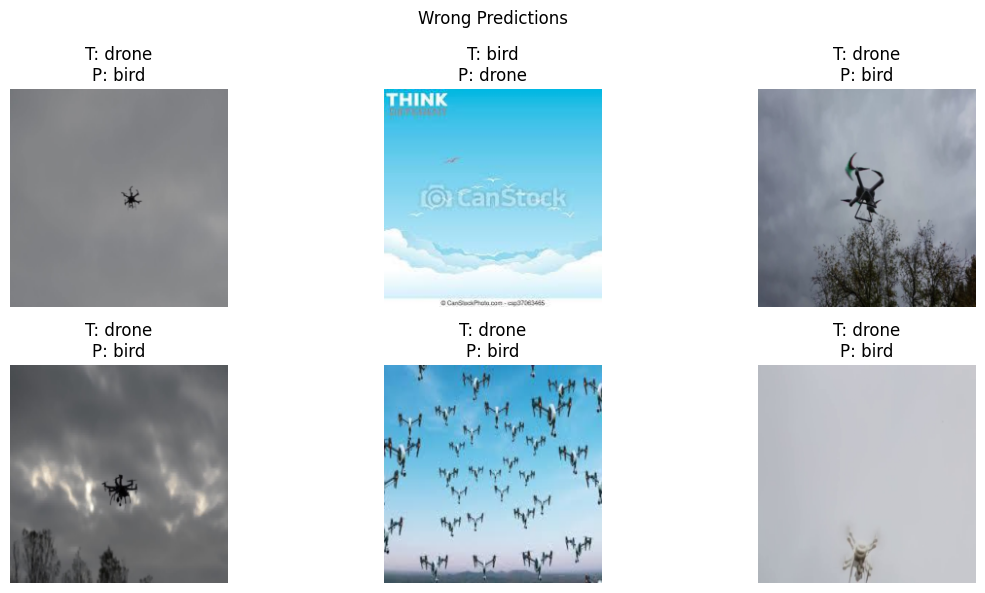

In [23]:
show_wrong_predictions(vit, test_loader, dataset.classes)

## Улучшение бейзлайна

### Гипотезы для улучшения

1. **Усиленные аугментации.** Модель должна стать устойчивой к масштабу и смещению объекта, а также к освещению и фону.

2. **Попробовать другие модели.** Для получения лучших результатов можно рассмотреть: `EfficientNet`, `MobileNetV3`, `ResNet50`, `ConvNeXT-Tiny`.

3. **Подбор гиперпараметров.**


### Проверка гипотез

1. Усиленные аугментации

In [13]:
train_transform_aug = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3, 0.3, 0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

dataset_aug = ImageFolder(path, transform=train_transform_aug)
dataset_test_upd = ImageFolder(path, transform=test_transform)

train_data_aug = Subset(dataset_aug, train_indices)
test_data_upd = Subset(dataset_test_upd, test_indices)

train_loader_aug = DataLoader(train_data_aug, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
test_loader_upd = DataLoader(test_data_upd, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

2. Испытание других моделей

In [14]:
def create_model(name):
    match name:
        case 'resnet18':
            model = models.resnet18(weights="DEFAULT")
            model.fc = nn.Linear(model.fc.in_features, 2)
        case 'resnet50':
            model = models.resnet50(weights="DEFAULT")
            model.fc = nn.Linear(model.fc.in_features, 2)
        case 'efficientnet':
            model = models.efficientnet_b0(weights="DEFAULT")
            model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
        case 'mobilenet':
            model = models.mobilenet_v3_small(weights="DEFAULT")
            model.classifier[3] = nn.Linear(model.classifier[3].in_features, 2)
        case 'convnext':
            model = models.convnext_tiny(weights="DEFAULT")
            model.classifier[2] = nn.Linear(model.classifier[2].in_features, 2)
        case 'vit':
            model = models.vit_b_16(weights='DEFAULT')
            model.heads.head = nn.Linear(model.heads.head.in_features, 2)
    return model


3. Подбор гиперпараметров
Подбирать будем `learning rate` и `optimizer`.

In [15]:
def create_optimizer(model, lr, opt_name):
    if opt_name == 'adam':
        return optim.Adam(model.parameters(), lr=lr)
    elif opt_name == 'sgd':
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)


Запуск экспериментов

In [16]:
models_to_test = [
    "resnet18", "resnet50", "efficientnet", "mobilenet",
    "convnext", "vit"
]

lr = 1e-4
opt_name = 'adam'

results = []

for model_name in models_to_test:
    print(f"Model: {model_name}, lr: {lr}, opt: {opt_name}\n")

    model = create_model(model_name).to(device)
    optimizer = create_optimizer(model, lr, opt_name)
    criterion = nn.CrossEntropyLoss()

    model.train()
    for epoch in range(1):
        total_loss = 0
        for x, y in tqdm(train_loader_aug):
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
        print(f"epoch={epoch+1}, loss={total_loss:.3f}")

    targets, preds = evaluate(model, test_loader_upd)
    acc = accuracy_score(targets, preds)
    f1 = f1_score(targets, preds)

    print(f"F1: {f1}")
    print(f"Accuracy: {acc}\n")

    results.append({
        "model": model_name,
        "lr": lr,
        "optimizer": opt_name,
        "accuracy": acc,
        "f1": f1,
    })


Model: resnet18, lr: 0.0001, opt: adam



100%|██████████| 103/103 [00:33<00:00,  3.06it/s]


epoch=1, loss=11.900
F1: 0.9921104536489151
Accuracy: 0.9902676399026764

Model: resnet50, lr: 0.0001, opt: adam



100%|██████████| 103/103 [00:47<00:00,  2.18it/s]


epoch=1, loss=15.497
F1: 0.9940944881889764
Accuracy: 0.9927007299270073

Model: efficientnet, lr: 0.0001, opt: adam



...

epoch=1, loss=27.098
F1: 0.9536423841059603
Accuracy: 0.940389294403893

Model: convnext, lr: 0.0001, opt: adam



100%|██████████| 103/103 [02:55<00:00,  1.70s/it]


epoch=1, loss=8.294
F1: 0.9950738916256158
Accuracy: 0.9939172749391727

Model: vit, lr: 0.0001, opt: adam



100%|██████████| 103/103 [06:24<00:00,  3.73s/it]


epoch=1, loss=11.707
F1: 0.9901960784313726
Accuracy: 0.9878345498783455



In [17]:
df = pd.DataFrame(results)
df = df.sort_values(by="f1", ascending=False)
df

,model,lr,optimizer,accuracy,f1
2,efficientnet,0.0001,adam,0.993917,0.995112
4,convnext,0.0001,adam,0.993917,0.995074
1,resnet50,0.0001,adam,0.992701,0.994094
0,resnet18,0.0001,adam,0.990268,0.992110
5,vit,0.0001,adam,0.987835,0.990196
3,mobilenet,0.0001,adam,0.940389,0.953642


### Улучшенный бейзлайн

По результатам проверки гипотез можно сделать вывод, что аугментации дают небольшой прирост точности модели, т.к. *F1-Score* модели `ResNet18` на первой эпохе был равен 0.98912, а при аугментации стал 0.99211. Однако использование аугментации зачастую требует значительного увеличения количества эпох, поэтому при малом количестве эпох модель без аугментации обучается быстрее и даёт лучший результат.

Модель `EfficientNet` показала лучший *F1-Score*.


### Обучение моделей с улучшенным бейзлайном

Произведём подбор гиперпараметров для лучшей модели: `EfficientNet`. Также увеличим количество эпох до 5. На 5 эпохах лучший результат получает модель без использования аугментации, поэтому будем использовать `train_loder`.

In [27]:
model_name = 'efficientnet'
lrs = [1e-4, 1e-3]
optimizers = ['adam', 'sgd']

results = []
for lr in lrs:
    for opt_name in optimizers:
        print(f"Model: {model_name}, lr: {lr}, opt: {opt_name}\n")

        model = create_model(model_name).to(device)
        optimizer = create_optimizer(model, lr, opt_name)
        criterion = nn.CrossEntropyLoss()

        model.train()
        for epoch in range(5):
            total_loss = 0
            for x, y in tqdm(train_loader_aug):
                x, y = x.to(device), y.to(device)

                optimizer.zero_grad()
                out = model(x)
                loss = criterion(out, y)

                loss.backward()
                optimizer.step()

                total_loss += loss.item()
            print(f"epoch={epoch+1}, loss={total_loss:.3f}")

        targets, preds = evaluate(model, test_loader_upd)
        acc = accuracy_score(targets, preds)
        f1 = f1_score(targets, preds)

        print(f"F1: {f1}")
        print(f"Accuracy: {acc}\n")

        results.append({
            "model": model_name,
            "lr": lr,
            "optimizer": opt_name,
            "accuracy": acc,
            "f1": f1,
        })

Model: efficientnet, lr: 0.0001, opt: adam



100%|██████████| 103/103 [00:54<00:00,  1.88it/s]


epoch=1, loss=25.849


100%|██████████| 103/103 [00:51<00:00,  1.99it/s]


epoch=2, loss=6.443


...

epoch=3, loss=14.779


100%|██████████| 103/103 [00:52<00:00,  1.96it/s]


epoch=4, loss=10.356


100%|██████████| 103/103 [00:52<00:00,  1.96it/s]


epoch=5, loss=8.930
F1: 0.9951124144672532
Accuracy: 0.9939172749391727



In [28]:
df = pd.DataFrame(results)
df = df.sort_values(by="f1", ascending=False)
df

,model,lr,optimizer,accuracy,f1
3,efficientnet,0.0010,sgd,0.993917,0.995112
0,efficientnet,0.0001,adam,0.993917,0.995103
2,efficientnet,0.0010,adam,0.991484,0.993131
1,efficientnet,0.0001,sgd,0.935523,0.949087


Можно заметить, что результат получился хуже, чем у `resnet18` без аугментации при нескольких эпохах. Обучим модель `EfficientNet` без аугментаций, чтобы получить лучший результат.

In [22]:
model_name = 'efficientnet'
lrs = [1e-4, 1e-3]
optimizers = ['adam', 'sgd']

results = []

best_model = None
best_f1 = 0.0

for lr in lrs:
    for opt_name in optimizers:
        print(f"Model: {model_name}, lr: {lr}, opt: {opt_name}\n")

        model = create_model(model_name).to(device)
        optimizer = create_optimizer(model, lr, opt_name)
        criterion = nn.CrossEntropyLoss()

        model.train()
        for epoch in range(5):
            total_loss = 0
            for x, y in tqdm(train_loader):
                x, y = x.to(device), y.to(device)

                optimizer.zero_grad()
                out = model(x)
                loss = criterion(out, y)

                loss.backward()
                optimizer.step()

                total_loss += loss.item()
            print(f"epoch={epoch+1}, loss={total_loss:.3f}")

        targets, preds = evaluate(model, test_loader)
        acc = accuracy_score(targets, preds)
        f1 = f1_score(targets, preds)

        if f1 > best_f1:
            best_f1 = f1
            best_model = model

        print(f"F1: {f1}")
        print(f"Accuracy: {acc}\n")

        results.append({
            "model": model_name,
            "lr": lr,
            "optimizer": opt_name,
            "accuracy": acc,
            "f1": f1,
        })

Model: efficientnet, lr: 0.0001, opt: adam



100%|██████████| 103/103 [00:53<00:00,  1.93it/s]


epoch=1, loss=20.755


100%|██████████| 103/103 [00:51<00:00,  2.01it/s]


epoch=2, loss=4.110


...

epoch=3, loss=10.830


100%|██████████| 103/103 [00:51<00:00,  2.01it/s]


epoch=4, loss=8.186


100%|██████████| 103/103 [00:52<00:00,  1.98it/s]


epoch=5, loss=5.671
F1: 0.9941176470588236
Accuracy: 0.9927007299270073



In [23]:
df = pd.DataFrame(results)
df = df.sort_values(by="f1", ascending=False)
df

,model,lr,optimizer,accuracy,f1
0,efficientnet,0.0001,adam,0.998783,0.999019
2,efficientnet,0.0010,adam,0.995134,0.996086
3,efficientnet,0.0010,sgd,0.992701,0.994118
1,efficientnet,0.0001,sgd,0.961071,0.968254


### Оценка качества моделей

По итогу модель `EfficientNet` показала лучший *F1-Score*:  0.999019 без использования аугментаций. С аугментациями результат был около 0.995, что хуже. Возможно с большим количеством эпох результат получился бы лучше, так как аугментации позволяют регуляризовать данные и сделать обучение качественнее.

У моделей из обычного бейзлайна лучший *F1-Score* был 0.996.

*Confusion Matrix* для этой модели:

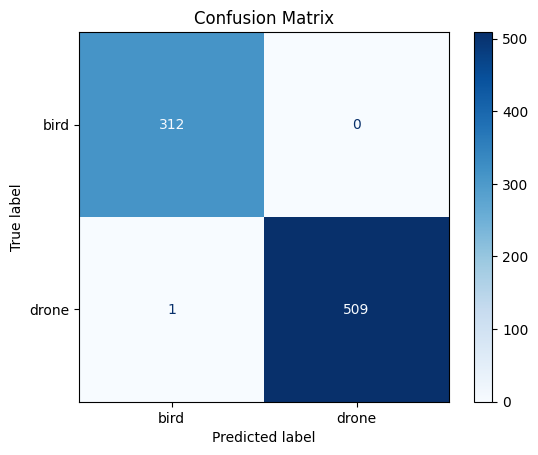

In [25]:
plot_confusion_matrix(best_model, test_loader, dataset.classes)

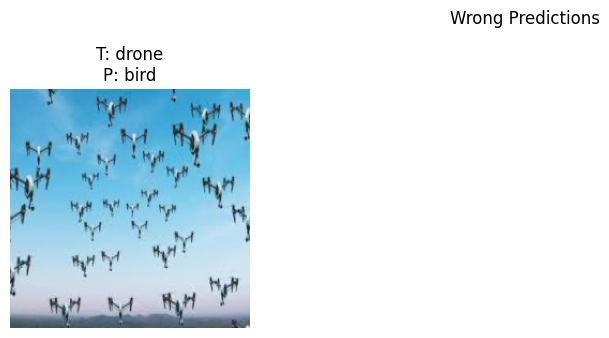

In [26]:
show_wrong_predictions(best_model, test_loader, dataset.classes)

Можно заметить, что осталось только одно изображение из тестовой выборки, которое модель неверно оценивает. Вероятно дело в уникальности изображения, ведь дроны редко летают стаями, обычно это делают птицы...

## Имплементация модели

Спроектируем модель под задачу классификации дронов и птиц. Важно учитывать то, что объекты могут быть разного масштаба и находится не в центре, фон часто сложный.

Идея архитектуры:
- Multi-scale блоки позволят учитывать разные размеры объектов;
- Residual для стабильности;
- Attention - игнорирование фона;



**Multi-scale блок** - извлекает признаки на разных масштабах. Модель учитывает: мелкие детали ($3 \times 3$), средние детали ($5 \times 5$) и крупные ($7 \times 7$).

In [29]:
class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.conv3 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv5 = nn.Conv2d(in_ch, out_ch, 5, padding=2)
        self.conv7 = nn.Conv2d(in_ch, out_ch, 7, padding=3)

        self.bn = nn.BatchNorm2d(out_ch * 3)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x1 = self.conv3(x)
        x2 = self.conv5(x)
        x3 = self.conv7(x)

        x = torch.cat([x1, x2, x3], dim=1)
        return self.relu(self.bn(x))


**SE (Squeeze-and-Excitation) Attention блок** - механизм внимания по каналам. Сначала выполняется сжатие, чтобы получить информацию о каждом канале, затем вычисляются веса важности каналов. Эти веса используются для масштабирования исходных признаков, усиливая важные и подавляя менее значимые.

In [30]:
class SEBlock(nn.Module):
    def __init__(self, ch, reduction=16):
        super().__init__()

        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(ch, ch // reduction),
            nn.ReLU(),
            nn.Linear(ch // reduction, ch),
            nn.Sigmoid(),
        )
    def forward(self, x):
        w = self.fc(x).view(x.size(0), -1, 1, 1)
        return x * w


**Residual (остаточный) блок** - добавляет вход к выходу слоя. Это облегчает обучение, улучшает прохождение градиентов и позволяет модели учить только изменения признаков, а не всю функцию целиком.

In [31]:
class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1),
            nn.BatchNorm2d(ch),
            nn.ReLU(),
            nn.Conv2d(ch, ch, 3, padding=1),
            nn.BatchNorm2d(ch),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.conv(x) + x)


**Downsample блок** - уменьшает пространственное разрешение изображения и увеличивает число каналов. Это позволяет извлекать более абстрактные признаки и снижать вычислительную сложность на последующих слоях.

In [32]:
class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.conv = nn.Conv2d(in_ch, out_ch, 3, stride=2, padding=1)
        self.bn = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))


Финальная модель.

In [33]:
class DroneBirdNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
        )

        self.layer1 = nn.Sequential(
            MultiScaleBlock(32, 32),
            SEBlock(96),
            ResBlock(96),
            DownBlock(96, 128),
        )

        self.layer2 = nn.Sequential(
            MultiScaleBlock(128, 64),
            SEBlock(192),
            ResBlock(192),
            DownBlock(192, 256),
        )

        self.layer3 = nn.Sequential(
            MultiScaleBlock(256, 128),
            SEBlock(384),
            ResBlock(384),
        )

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(384, 2),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return self.head(x)


### Обучение имлементированной модели

In [34]:
model = DroneBirdNet()
model = train_model(model, 3)

100%|██████████| 103/103 [12:59<00:00,  7.57s/it]


Accuracy: 0.829683698296837
F1-Score: 0.8643410852713178



100%|██████████| 103/103 [13:08<00:00,  7.66s/it]


Accuracy: 0.8832116788321168
F1-Score: 0.9064327485380117



100%|██████████| 103/103 [13:24<00:00,  7.81s/it]


Accuracy: 0.9306569343065694
F1-Score: 0.9438423645320198



### Оценка качества моделей

При обучении модели с собственной архитектурой на 3 эпохах был получен *F1-Score*=0.94384

### Сравнение с обычным бейзлайном и вывод

Ранее предобученные модели показывали следующие результаты:
- ResNet18 - 0.99706
- Vit - 0.98921
Эти значения превышают *F1-Score* модели `DroneBirdNet`.

Предобученные модели ResNet18 и ViT показали существенно более высокое качество по сравнению с `DroneBirdNet`. Так происходит потому, что они уже обучены на больших датасетах и имеют более сложные и оптимизированные архитектуры.

При этом, хотя собственная модель показывает более низкое качества, она остаётся работоспособной. Модель `DroneBirdNet` показывает *F1-Score* ~ 0.9, что является приемлемым результатом для непредобученной модели.

### Техники из улучшенного бейзлайна

In [36]:
lrs = [1e-3, 1e-4]
optimizers = ['adam', 'sgd']

results = []

for lr in lrs:
    for opt_name in optimizers:
        print(f"\nDroneBirdNet lr={lr} optim={opt_name}")

        model = DroneBirdNet().to(device)
        optimizer = create_optimizer(model, lr, opt_name)
        criterion = nn.CrossEntropyLoss()

        model.train()
        for epoch in range(1):
            total_loss = 0
            for x, y in tqdm(train_loader_aug):
                x, y = x.to(device), y.to(device)

                optimizer.zero_grad()
                out = model(x)
                loss = criterion(out, y)

                loss.backward()
                optimizer.step()

                total_loss += loss.item()
            print(f"epoch={epoch+1}, loss={total_loss:.3f}")

        targets, preds = evaluate(model, test_loader_upd)
        acc = accuracy_score(targets, preds)
        f1 = f1_score(targets, preds)
        print(f"Accuracy: {acc:.4f}, F1: {f1:.4f}")

        results.append({
            "lr": lr,
            "optimizer": opt_name,
            "accuracy": acc,
            "f1": f1,
        })



DroneBirdNet lr=0.001 optim=adam


100%|██████████| 103/103 [14:51<00:00,  8.65s/it]


epoch=1, loss=64.728
Accuracy: 0.7433, F1: 0.7969

DroneBirdNet lr=0.001 optim=sgd


100%|██████████| 103/103 [16:53<00:00,  9.84s/it]


epoch=1, loss=58.453
Accuracy: 0.8212, F1: 0.8705

DroneBirdNet lr=0.0001 optim=adam


100%|██████████| 103/103 [18:15<00:00, 10.64s/it]


epoch=1, loss=56.692
Accuracy: 0.7981, F1: 0.8477

DroneBirdNet lr=0.0001 optim=sgd


100%|██████████| 103/103 [17:45<00:00, 10.34s/it]


epoch=1, loss=60.716
Accuracy: 0.7543, F1: 0.8209


In [37]:
df = pd.DataFrame(results)
df = df.sort_values(by="f1", ascending=False)
df

,lr,optimizer,accuracy,f1
1,0.0010,sgd,0.821168,0.870485
2,0.0001,adam,0.798054,0.847706
3,0.0001,sgd,0.754258,0.820922
0,0.0010,adam,0.743309,0.796920


Получается, что лучшие параметры для модели `DroneBirdNet` это оптимизатор `adam` и learning_rate=0.0001.

Можно заметить, что при использовании аугментации *F1-Score* модели стал меньше. Это объясняется тем, что при использовании аугментации скорость обучения модели замедлилась, поэтому эпох не хватает.

### Обучение и оценка качества модели

Обучим имплементированную модель на большем количестве эпох с лучшими параметрами.

In [39]:
model = DroneBirdNet().to(device)
optimizer = create_optimizer(model, 1e-4, 'adam')
criterion = nn.CrossEntropyLoss()

model.train()
for epoch in range(5):
    total_loss = 0
    for x, y in tqdm(train_loader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    print(f"epoch={epoch+1}, loss={total_loss:.3f}")


100%|██████████| 103/103 [18:28<00:00, 10.76s/it]


epoch=1, loss=44.274


100%|██████████| 103/103 [18:54<00:00, 11.01s/it]


epoch=2, loss=33.669


100%|██████████| 103/103 [16:38<00:00,  9.70s/it]


epoch=3, loss=28.016


100%|██████████| 103/103 [17:40<00:00, 10.29s/it]


epoch=4, loss=22.684


100%|██████████| 103/103 [15:34<00:00,  9.07s/it]

epoch=5, loss=20.408


Расчёт метрик

In [40]:
print_metrics(model, test_loader)

Accuracy: 0.9549878345498783
F1-Score: 0.9630369630369631



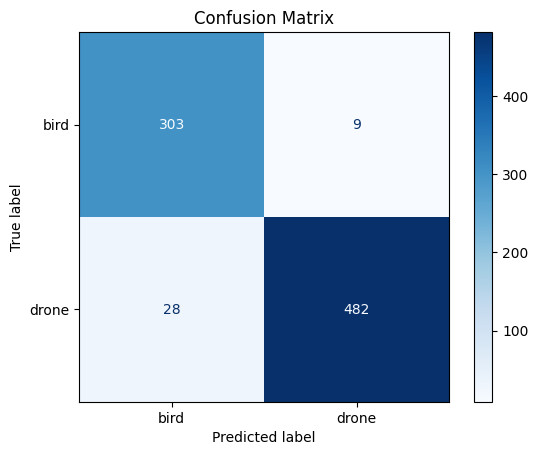

In [42]:
plot_confusion_matrix(model, test_loader, dataset.classes)

### Сравнение с улучшенным бейзлайном

После увелечения числа эпох до 5, разработанная модель `DroneBirdNet` показала улучшение качества до *F1-Score* = 0.96304.
Результаты улучшились, но `DroneBirdNet` всё ещё значительно уступает предобученным моделям и требует гораздо больше времени на обучение.

В свою очередь модель `EfficientNet` достигает почти идеального качества, что говорит о эффективности предобученных признаков и архитектуры модели.

## Вывод

В ходе выполнения лабораторной работы была решена задача классификации изображений воздушных объектов (дрон / птица) с использованием современных методов компьютерного зрения. Построен базовый подход с использованием предобученных моделей библиотеки `torchvision`. Были сформулированы гипотезы, на основе которых построен улучшенный бейзлайн. В результате удалось повысить качество моделей и определить наиболее эффективные конфигурации.

Отдельное внимание было уделено самостоятельной реализации модели. Разработанная модель достигла F1 ≈ 0.96, что подтверждает её работоспособность, но также демонстрирует преимущество предобученных решений при ограниченном объёме данных.

Полученные знания и навыки могут пригодиться в системах видеонаблюдения, беспилотных технологиях, мониторинге окружающей среды и других прикладных задачах.